# Urban Energy PV Dispatch

Analyze local load/PV time series and run a small pandapower feeder check at peak net load.

This OpenGeoLab case is self-contained: all inputs live in `data/`, and outputs are written to `outputs/`.

Inspired by PyPSA and pandapower example workflows for power systems and urban energy screening.

In [1]:
import os
os.environ.setdefault("PROJ_DATA", "/opt/conda/share/proj")
os.environ.setdefault("PROJ_LIB", "/opt/conda/share/proj")
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pypsa
import pandapower as pp
from IPython.display import display

DATA = Path('data')
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)
ts = pd.read_csv(DATA / 'energy_timeseries.csv', parse_dates=['time'])
print({'records': len(ts), 'pypsa': pypsa.__version__, 'pandapower': pp.__version__})
display(ts.head())


{'records': 48, 'pypsa': '1.2.3', 'pandapower': '3.4.0'}


,time,load_mw,pv_mw,price
0,2026-07-01 00:00:00,60.601,0.724,0.592
1,2026-07-01 01:00:00,63.055,0.000,0.622
2,2026-07-01 02:00:00,61.673,0.342,0.571
3,2026-07-01 03:00:00,55.776,0.000,0.653
4,2026-07-01 04:00:00,54.511,0.000,0.620


In [2]:
ts['net_load_mw'] = ts['load_mw'] - ts['pv_mw']
ts['pv_share'] = ts['pv_mw'] / ts['load_mw']
summary = ts[['load_mw', 'pv_mw', 'net_load_mw', 'pv_share']].describe().round(3)
display(summary)


,load_mw,pv_mw,net_load_mw,pv_share
count,48.000,48.000,48.000,48.000
mean,54.037,12.375,41.662,0.223
std,6.545,14.717,14.231,0.255
min,42.115,0.000,19.009,0.000
25%,48.395,0.000,27.861,0.000
50%,54.328,1.884,44.162,0.035
75%,59.594,26.180,54.236,0.473
max,64.729,39.121,64.381,0.645


In [3]:
net = pp.create_empty_network()
b1 = pp.create_bus(net, vn_kv=20, name='Substation')
b2 = pp.create_bus(net, vn_kv=20, name='District load')
pp.create_ext_grid(net, b1, vm_pu=1.02)
pp.create_line_from_parameters(net, b1, b2, length_km=2.0, r_ohm_per_km=0.18, x_ohm_per_km=0.08, c_nf_per_km=10, max_i_ka=0.4)
peak = ts.loc[ts['net_load_mw'].idxmax()]
pp.create_load(net, b2, p_mw=float(peak.net_load_mw), q_mvar=float(peak.net_load_mw * 0.22))
pp.runpp(net)
display(net.res_bus)
display(net.res_line)


,vm_pu,va_degree,p_mw,q_mvar
0,1.020000,0.000000,-68.685626,-16.074538
1,0.953176,-0.766489,64.381000,14.163820


,p_from_mw,q_from_mvar,p_to_mw,q_to_mvar,pl_mw,ql_mvar,i_from_ka,i_to_ka,i_ka,vm_from_pu,va_from_degree,vm_to_pu,va_to_degree,loading_percent
0,68.685626,16.074538,-64.381,-14.16382,4.304626,1.910718,1.99643,1.996446,1.996446,1.02,0.0,0.953176,-0.766489,499.111386


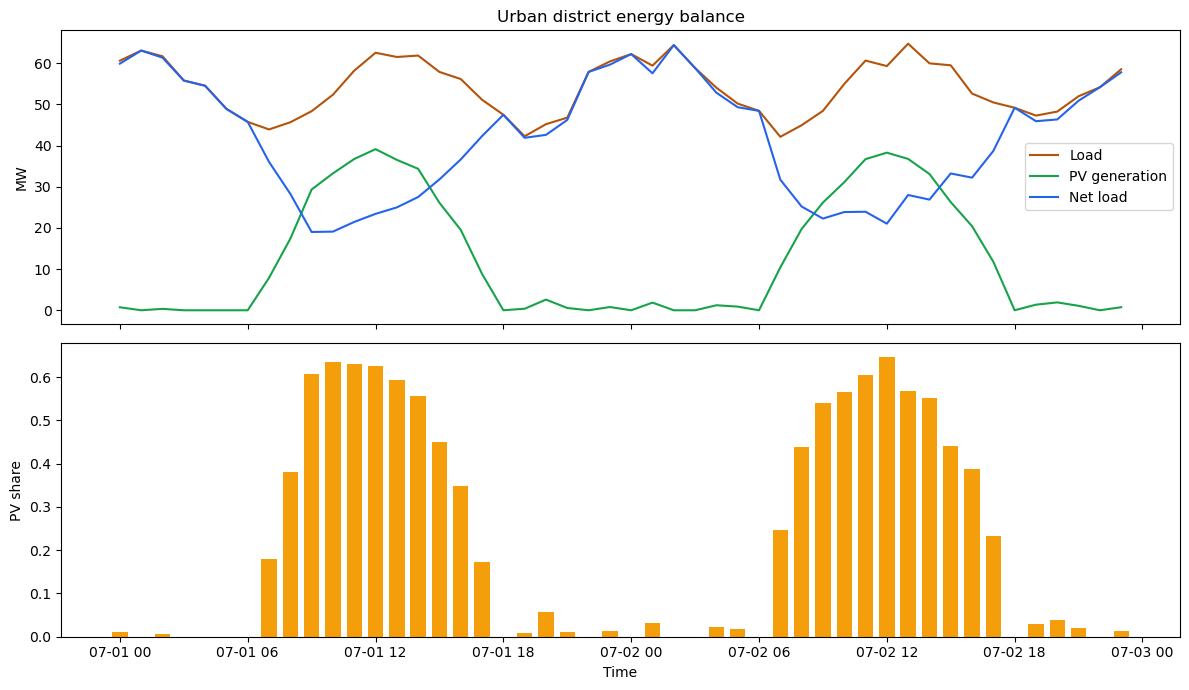

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(ts['time'], ts['load_mw'], label='Load', color='#b45309')
axes[0].plot(ts['time'], ts['pv_mw'], label='PV generation', color='#16a34a')
axes[0].plot(ts['time'], ts['net_load_mw'], label='Net load', color='#2563eb')
axes[0].legend(); axes[0].set_ylabel('MW'); axes[0].set_title('Urban district energy balance')
axes[1].bar(ts['time'], ts['pv_share'], color='#f59e0b', width=0.03)
axes[1].set_ylabel('PV share'); axes[1].set_xlabel('Time')
fig.tight_layout()
fig.savefig(OUT / 'energy_balance.png', dpi=160)
plt.show()


In [5]:
print(f"Peak net load: {peak.net_load_mw:.2f} MW at {peak.time}")
print(f"Minimum voltage at peak: {net.res_bus.vm_pu.min():.4f} pu")


Peak net load: 64.38 MW at 2026-07-02 02:00:00
Minimum voltage at peak: 0.9532 pu
